# Experiment 7: Principal Component Analysis (PCA)

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Dimensionality Reduction with PCA  
**Dataset:** `sklearn.datasets.load_breast_cancer()` (569 samples, 30 features)  
**Lab Book Reference:** §11 Principal Component Analysis, page 49–52

---

## 🎯 Objective

Apply **Principal Component Analysis** (PCA) to the 30-feature Breast Cancer
dataset to reduce the dimensionality to 2 and 3 principal components for
visualisation.  We also examine how much variance is explained by each
principal component.

## 🧠 Key Concepts

- **Dimensionality reduction:** PCA finds a smaller set of *uncorrelated*
  linear combinations of the original features that still capture most of the
  variance in the data.
- **Steps:**
  1. **Standardise** features (zero mean, unit variance).
  2. Compute the **covariance matrix** of the standardised data.
  3. Compute its **eigenvectors** and **eigenvalues**.
  4. Sort eigenvectors by descending eigenvalue; the top-k vectors are the
     first k principal components.
  5. **Project** the data onto the selected principal components.
- **Explained variance ratio:** the proportion of total variance captured by
  each principal component.  We typically retain enough components to explain
  ≥ 95% of total variance.
- **Why scale?** without standardisation, features with the largest numeric
  ranges (e.g. `area_mean` ~ 10³) would dominate the eigenvectors.

## ▶️ How to Run

> **Option A — Google Colab (recommended):**
> 1. Upload the entire `ML-Lab-Activities` folder to Google Drive.
> 2. Open `07-PCA/07_PCA.ipynb` from Drive in Colab.
>
> **Option B — Local Jupyter:**
> ```bash
> pip install -r requirements.txt
> jupyter notebook 07-PCA/07_PCA.ipynb
> ```
>
> **Option C — Headless:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   07-PCA/07_PCA.ipynb --output 07_PCA.ipynb
> ```

No external dataset is needed — we use `sklearn.datasets.load_breast_cancer()`,
which downloads the canonical Wisconsin Diagnostic Breast Cancer (WDBC) data
on first use.  Generated figures are auto-saved to `./outputs/`.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '07-PCA'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Patch plt.show so every figure is also auto-saved as PNG
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load the Breast Cancer Dataset

Lab Book page 50 uses `sklearn.datasets.load_breast_cancer()` — 569 samples,
30 numeric features, binary target (0 = malignant, 1 = benign).

In [3]:
data = load_breast_cancer()
print("Keys of the dataset:")
print(data.keys())

print("\nTarget names:", data['target_names'])
print("\nFeature names (first 5):")
print(data['feature_names'][:5])
print("\nShape of data array:", data['data'].shape)

Keys of the dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Target names: ['malignant' 'benign']

Feature names (first 5):
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Shape of data array: (569, 30)


## 3. Build a DataFrame

In [4]:
df1 = pd.DataFrame(data['data'], columns=data['feature_names'])
print(f"DataFrame shape: {df1.shape}")
display(df1.head())
print("\nFeature statistics (first 4 features):")
display(df1.iloc[:, :4].describe().round(3))

DataFrame shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Feature statistics (first 4 features):


,mean radius,mean texture,mean perimeter,mean area
count,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889
std,3.524,4.301,24.299,351.914
min,6.981,9.710,43.790,143.500
25%,11.700,16.170,75.170,420.300
50%,13.370,18.840,86.240,551.100
75%,15.780,21.800,104.100,782.700
max,28.110,39.280,188.500,2501.000


## 4. Standardisation

Standardise features to zero mean and unit variance.  Without this step,
features like `mean area` (range 140 – 2500) would dominate the
principal components.

In [5]:
sc = StandardScaler()
sc.fit(df1)
scaled_data = sc.transform(df1)
print(f"Scaled data shape: {scaled_data.shape}")
print(f"Mean per feature (should be ~0): {scaled_data.mean(axis=0).round(3)[:5]}")
print(f"Std  per feature (should be 1):  {scaled_data.std(axis=0).round(3)[:5]}")

Scaled data shape: (569, 30)
Mean per feature (should be ~0): [-0. -0. -0. -0.  0.]
Std  per feature (should be 1):  [1. 1. 1. 1. 1.]


## 5. Apply PCA — Reduce to 3 Components

Lab Book page 51 fits PCA with `n_components=3` and produces a 569 × 3
projected dataset.

In [6]:
principal = PCA(n_components=3)
principal.fit(scaled_data)
x = principal.transform(scaled_data)
print(f"Projected data shape: {x.shape}")

Projected data shape: (569, 3)


## 6. Inspect the Principal Components

In [7]:
print("Principal components (each row = one PC, each col = one original feature):")
print(principal.components_.shape)
print("\nFirst principal component (top 5 weights):")
print(principal.components_[0][:5].round(4))

print("\nExplained variance ratio:")
print(principal.explained_variance_ratio_)

print(f"\nTotal variance captured by 3 components: "
      f"{principal.explained_variance_ratio_.sum()*100:.2f}%")

Principal components (each row = one PC, each col = one original feature):
(3, 30)

First principal component (top 5 weights):
[0.2189 0.1037 0.2275 0.221  0.1426]

Explained variance ratio:
[0.44272026 0.18971182 0.09393163]

Total variance captured by 3 components: 72.64%


## 7. 2-D Scatter Plot — PC1 vs PC2

We project the 30-D data onto its first 2 principal components and colour
the points by diagnosis (malignant vs benign).  Even with just 2 PCs the
two classes are largely separable — that is why PCA is such a popular
preprocessing step.

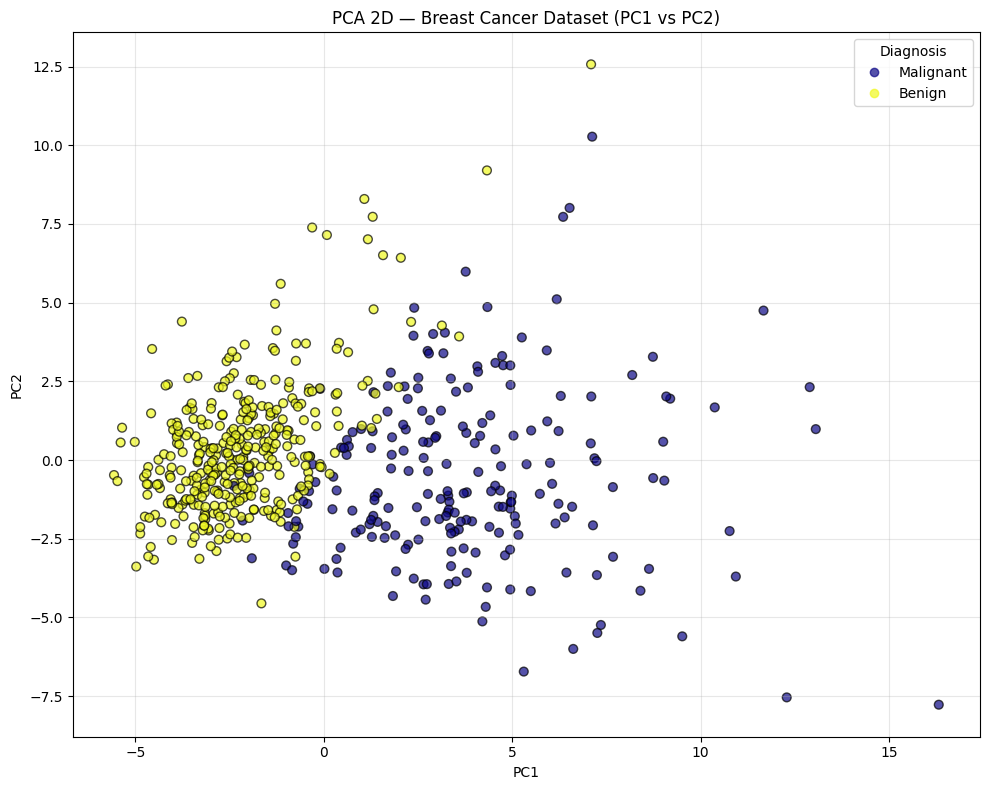

In [8]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(x[:, 0], x[:, 1], c=data['target'],
                      cmap='plasma', s=40, edgecolors='k', alpha=0.7)
plt.title('PCA 2D — Breast Cancer Dataset (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Malignant', 'Benign'],
           title='Diagnosis', loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 3-D Scatter Plot — PC1, PC2, PC3

Adding the third principal component gives a 3-D view of the data.

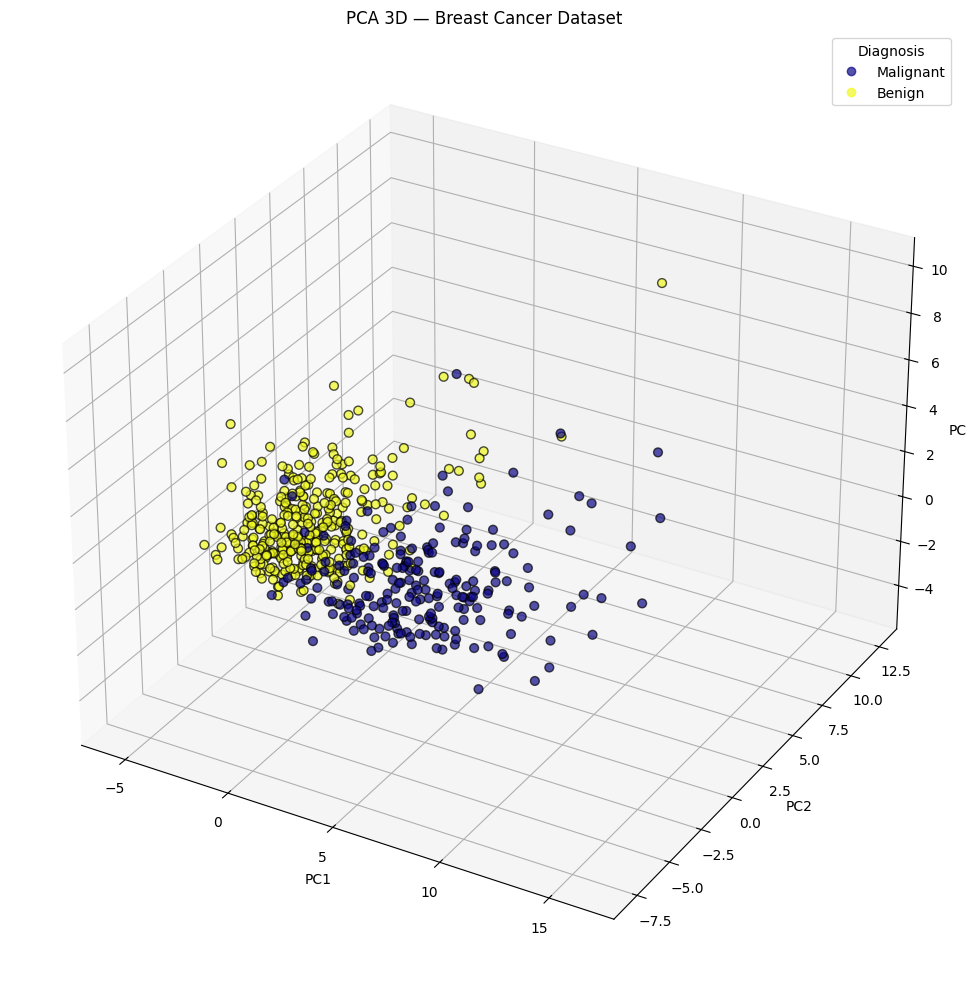

In [9]:
fig = plt.figure(figsize=(10, 10))
axis = fig.add_subplot(111, projection='3d')
sc3 = axis.scatter(x[:, 0], x[:, 1], x[:, 2],
                   c=data['target'], cmap='plasma', s=40, edgecolors='k', alpha=0.7)
axis.set_xlabel('PC1', fontsize=10)
axis.set_ylabel('PC2', fontsize=10)
axis.set_zlabel('PC3', fontsize=10)
axis.set_title('PCA 3D — Breast Cancer Dataset')
plt.legend(handles=sc3.legend_elements()[0],
           labels=['Malignant', 'Benign'],
           title='Diagnosis', loc='upper right')
plt.tight_layout()
plt.show()

## 9. Variance Explained — Cumulative Plot

To choose how many principal components to retain for downstream ML, look
at the **cumulative** variance explained.  A common target is to keep
enough PCs to explain ≥ 95% of total variance.

Top-10 explained variance ratios:
  PC 1: 0.4427  cumulative = 0.4427
  PC 2: 0.1897  cumulative = 0.6324
  PC 3: 0.0939  cumulative = 0.7264
  PC 4: 0.0660  cumulative = 0.7924
  PC 5: 0.0550  cumulative = 0.8473
  PC 6: 0.0402  cumulative = 0.8876
  PC 7: 0.0225  cumulative = 0.9101
  PC 8: 0.0159  cumulative = 0.9260
  PC 9: 0.0139  cumulative = 0.9399
  PC10: 0.0117  cumulative = 0.9516

Components needed for 95% variance: 10


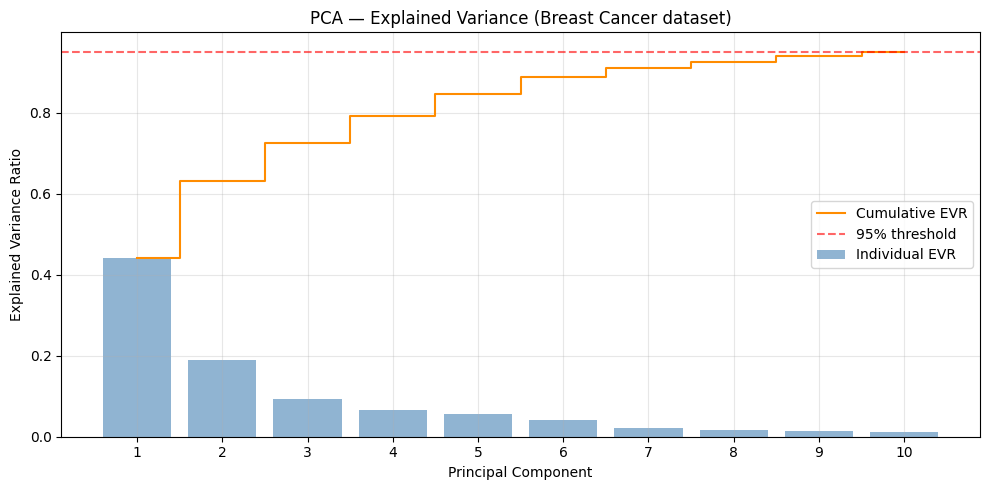

In [10]:
pca_full = PCA(n_components=30)
pca_full.fit(scaled_data)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

print("Top-10 explained variance ratios:")
for i, (e, c) in enumerate(zip(evr[:10], cum[:10]), 1):
    print(f"  PC{i:2d}: {e:.4f}  cumulative = {c:.4f}")

# Find number of components for 95% variance
n95 = int(np.argmax(cum >= 0.95) + 1)
print(f"\nComponents needed for 95% variance: {n95}")

plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), evr[:10], alpha=0.6, label='Individual EVR', color='steelblue')
plt.step(range(1, 11), cum[:10], where='mid', label='Cumulative EVR', color='darkorange')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
plt.xticks(range(1, 11))
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance (Breast Cancer dataset)')
plt.legend(loc='center right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Optional — Use PCA as Pre-processing for Logistic Regression

We use the first `n95` principal components (instead of the original 30
features) to train a Logistic Regression classifier.  This often achieves
similar accuracy with far fewer features.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_data, data['target'], test_size=0.3, random_state=42
)
pca95 = PCA(n_components=n95)
X_train_pca = pca95.fit_transform(X_train)
X_test_pca  = pca95.transform(X_test)

print(f"Original train shape : {X_train.shape}")
print(f"PCA-reduced shape    : {X_train_pca.shape}")
print(f"Variance retained    : {pca95.explained_variance_ratio_.sum()*100:.2f}%")

clf_full = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
clf_pca  = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_pca, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test))
acc_pca  = accuracy_score(y_test, clf_pca.predict(X_test_pca))

print(f"\nLogReg on original 30 features   — accuracy: {acc_full:.4f}")
print(f"LogReg on {n95} PCA components        — accuracy: {acc_pca:.4f}")

Original train shape : (398, 30)
PCA-reduced shape    : (398, 10)
Variance retained    : 95.20%

LogReg on original 30 features   — accuracy: 0.9825
LogReg on 10 PCA components        — accuracy: 0.9942


## 11. Heatmap of the First Two Principal Component Loadings

A heatmap of the top-N absolute loadings shows which original features
contribute most to each principal component.

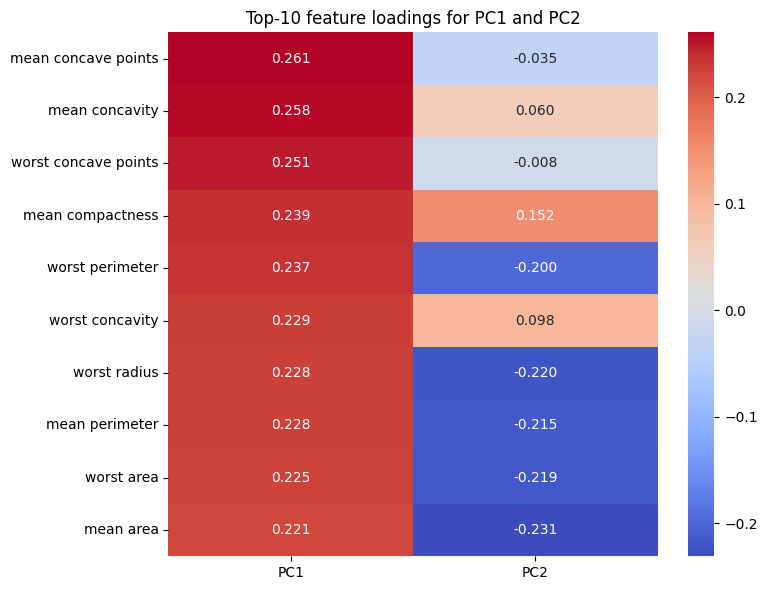

In [12]:
loading_df = pd.DataFrame(
    principal.components_[:2].T,
    index=data['feature_names'],
    columns=['PC1', 'PC2']
)
# Show top 10 by absolute PC1 weight
top = loading_df.reindex(loading_df.PC1.abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(8, 6))
sns.heatmap(top, cmap='coolwarm', annot=True, fmt='.3f', cbar=True)
plt.title('Top-10 feature loadings for PC1 and PC2')
plt.tight_layout()
plt.show()

## 📝 Exercises (Lab Book §11.4, page 52)

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Property sales insight.** Maggie is a real-estate agent and she is
   puzzled about why some of the properties her company manages have not
   been sold for more than six months.  Help Maggie by applying PCA to a
   real-estate dataset (price, area, location, age, beds, baths, ...) and
   identify the principal components that explain the most variance in
   "time-on-market".
2. **Identify the principal variable.** For the following dataset, identify
   which variable is the principal component (i.e. which single original
   variable has the highest absolute loading on PC1).

| Variable       | 1     | 2      | 3      |
|----------------|-------|--------|--------|
| Climate        | 0.190 | 0.017  | 0.207  |
| Housing        | 0.544 | 0.020  | 0.204  |
| Health         | 0.782 | -0.605 | 0.144  |
| Crime          | 0.365 | 0.294  | 0.585  |
| Transportation | 0.585 | 0.085  | 0.234  |
| Education      | 0.394 | 0.273  | 0.027  |
| Arts           | 0.985 | 0.126  | 0.111  |
| Recreation     | 0.520 | 0.402  | 0.519  |
| Economy        | 0.142 | 0.150  | 0.239  |


## 📚 Key Takeaways

- **PCA** is an unsupervised linear dimensionality reduction technique.
- **Standardisation** is mandatory before PCA — otherwise features with the
  largest numeric ranges dominate the principal components.
- The first few PCs usually capture most of the variance; we often retain
  enough PCs to explain ≥ 95%.
- The **explained variance ratio** of each PC measures how much of the
  total variance that PC accounts for.
- PCA is great for **visualisation** (project to 2-D or 3-D), **noise
  filtering**, and **feature extraction** before training another model.


## 🔗 References

- Lab Activity Book (23CSE301), §11 Principal Component Analysis, page 49–52.
- Scikit-learn user guide — PCA:
  <https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html>
- Jolliffe & Cadima (2016), *Principal component analysis: a review and
  recent developments*, Phil. Trans. R. Soc. A 374: 20150202.
